# Main Objective

### Analyze AI and Data Science job-market data to understand job demand, salaries, experience requirements, employment types, company sizes, locations, and remote-work opportunities.

## 📚 Table of Contents

1. [Project Objectives](#1-project-objectives)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Salary Analysis](#5-salary-analysis)
6. [Job Demand Analysis](#6-job-demand-analysis)
7. [Relationship Analysis](#7-relationship-analysis)
8. [Advanced Insights](#8-advanced-insights)
9. [Key Findings](#9-key-findings)
10. [Recommendations](#10-recommendations)
11. [Conclusion](#11-conclusion)
12. [Technologies Used](#12-technologies-used)

# 1. 🎯 Project Objectives

The main objectives of this project are:

- Analyze the demand for AI and Data Science job roles.
- Understand salary distributions across different roles.
- Analyze the relationship between experience and salary.
- Identify high-demand and high-paying job roles.
- Analyze employment types and company sizes.
- Explore remote-work opportunities.
- Compare job opportunities across different locations.
- Analyze relationships between numerical variables.
- Extract useful insights for students and job seekers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# # here we are taking df as data frame sample so that we can analysis easily
df=pd.read_csv("ai_and_data_science_job_2026.csv")

### 1. Dataset Overview

Before performing any analysis, we will inspect the dataset to understand its structure, columns, data types, missing values, and duplicate records.

In [7]:
print(f"this data frame has {df.shape[0]} Rows and {df.shape[1]} Columns ")

this data frame has 5000 Rows and 27 Columns 


In [9]:
# Get information about columns and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   str    
 1   experience_level            5000 non-null   str    
 2   employment_type             5000 non-null   str    
 3   company_size                5000 non-null   str    
 4   company_location            5000 non-null   str    
 5   employee_residence          5000 non-null   str    
 6   industry                    5000 non-null   str    
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   str    
 10  primary_language            5000 non-null   str    
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 non-null   

In [5]:
# Generate descriptive statistics for numerical columns
df.describe()

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


# Data Cleaning...

In [12]:
# check missing value..
df.isnull().sum()

job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

In [16]:
missing = df.isnull().sum()

missing[missing > 0]# this will return those column which has at least one missing values



Series([], dtype: int64)

In [18]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0]# this will check whether a column has a missing
# values if missing values is present then it will return the how much % values is missing


Series([], dtype: float64)

In [19]:
len(df)

5000

### check duplicate values

In [21]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]
# this will return the duplicated rows.... kind of filterization

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score


In [25]:
df = df.drop_duplicates()
# if duplicate values is present in the dataset than it will drop that row..

In [26]:
# than at last we should check our dataset again
df.duplicated().sum()

np.int64(0)

### Check data types....

In [27]:
df.dtypes

job_title                         str
experience_level                  str
employment_type                   str
company_size                      str
company_location                  str
employee_residence                str
industry                          str
remote_ratio                    int64
years_experience              float64
education_level                   str
primary_language                  str
has_ml_in_title                  bool
manages_people                   bool
team_size                       int64
certifications_count            int64
weekly_hours                  float64
uses_ai_tools_daily              bool
ai_tools_hours_per_week       float64
salary_currency                   str
salary_usd                      int64
equity_offered_pct            float64
bonus_pct                     float64
job_satisfaction_score        float64
interviews_to_offer             int64
switched_jobs_last_year          bool
upskilling_hours_per_month    float64
fears_ai_aut

### Check categorical values

In [30]:
df["job_title"].value_counts()

job_title
Data Scientist                   709
Data Engineer                    682
Data Analyst                     627
Machine Learning Engineer        593
AI Engineer                      506
Analytics Engineer               317
MLOps Engineer                   306
Business Intelligence Analyst    293
Research Scientist               269
LLM Engineer                     242
Data Science Manager             238
Computer Vision Engineer         218
Name: count, dtype: int64

In [32]:
df["job_title"].nunique()
# this will check how many types of job is exist or this cloumn contains these kinds of job


12

In [ ]:
# here we are analysis the categorical column experience level....
df["experience_level"].nunique()


5

In [ ]:
df["experience_level"].value_counts()
# so my analysis is for this kind of jobs most job sikkers are like senior and mid , 
#  for entry , lead etc oppourtunities are also there.....

experience_level
Mid          1613
Senior       1520
Entry         985
Lead          656
Executive     226
Name: count, dtype: int64

In [37]:
# analysis of categorical column employment types.......
df["employment_type"].nunique()

4

In [39]:
df["employment_type"].value_counts()
# so my analysis are most employable are for full time but some of are just for contract
# freelance and part-time .....

employment_type
Full-time    4159
Contract      418
Freelance     212
Part-time     211
Name: count, dtype: int64

In [40]:
df["company_size"].nunique()

3

In [ ]:
df["company_size"].value_counts()

company_size
M    2551
L    1288
S    1161
Name: count, dtype: int64

# Check numerical columns

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
remote_ratio,5000.0,43.08000,41.454280,0.0,0.000,50.000,100.000,100.000
years_experience,5000.0,8.36144,4.820808,0.0,4.800,8.100,11.500,23.700
team_size,5000.0,7.93620,2.647930,1.0,6.000,8.000,10.000,19.000
certifications_count,5000.0,1.82040,1.344212,0.0,1.000,2.000,3.000,8.000
weekly_hours,5000.0,44.34540,6.142761,24.4,40.100,44.400,48.500,67.300
ai_tools_hours_per_week,5000.0,8.43740,5.503637,0.0,3.300,8.500,12.625,25.200
salary_usd,5000.0,98605.40620,55369.310473,12000.0,55592.750,90572.000,129657.750,372347.000
equity_offered_pct,5000.0,0.13902,0.184243,0.0,0.017,0.072,0.175,1.264
bonus_pct,5000.0,10.80272,5.152959,0.0,7.100,10.600,14.200,30.800
job_satisfaction_score,5000.0,6.68532,1.364302,1.1,5.800,6.700,7.600,10.000


C:\Users\MSI2\AppData\Local\Temp\ipykernel_18108\3958497859.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="job_title",data=df,palette="coolwarm")


<Axes: xlabel='count', ylabel='job_title'>

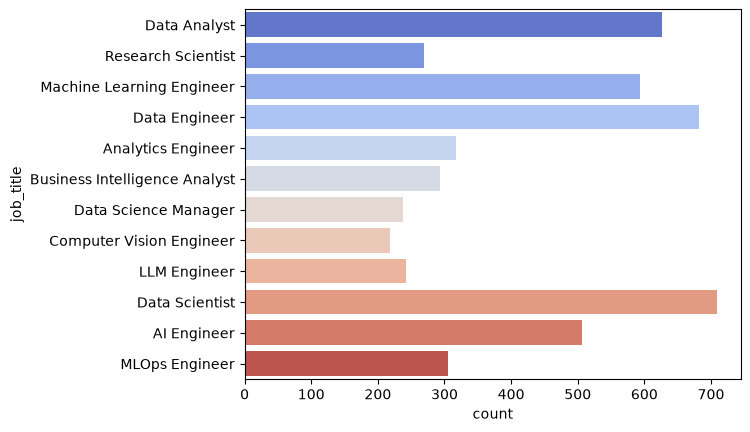

In [4]:
sns.countplot(y="job_title",data=df,palette="coolwarm")

In [3]:
df

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Data Analyst,Mid,Full-time,M,PL,PL,Finance,50,9.3,Masters,...,1.5,PLN,38810,0.182,12.0,7.3,2,False,7.8,4.8
4996,Machine Learning Engineer,Lead,Full-time,M,ES,ES,Technology,0,13.3,Self-taught,...,2.6,EUR,123368,0.000,11.0,5.5,7,False,4.0,1.3
4997,Data Science Manager,Senior,Full-time,M,PL,PL,Technology,50,8.1,Bachelors,...,9.7,PLN,86123,0.078,13.3,7.0,6,True,19.2,2.7
4998,Research Scientist,Senior,Freelance,M,PL,PL,Technology,0,12.9,Bachelors,...,10.7,PLN,76001,0.122,10.1,6.0,4,True,10.8,1.5


In [ ]:
# analysis of jobs in terms of ppo?
df["experience_level"].value_counts()

experience_level
Mid          1613
Senior       1520
Entry         985
Lead          656
Executive     226
Name: count, dtype: int64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_26960\3934958959.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="experience_level",data=df,palette="rainbow")


Text(0.5, 0, 'count.......')

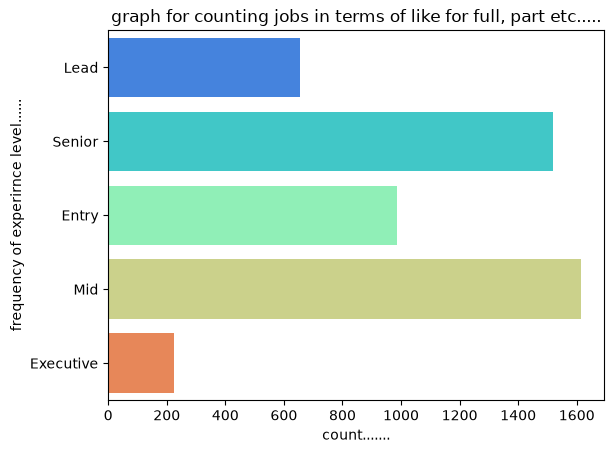

In [5]:
sns.countplot(y="experience_level",data=df,palette="rainbow")
plt.title("graph for counting jobs in terms of like for full, part etc.....")
plt.ylabel("frequency of experirnce level......")
plt.xlabel("count.......")

### so my analysis is most of the employer are at seniur and mid level while some of them are at lead , Executive and Entry level position

Text(0.5, 0, 'count.......')

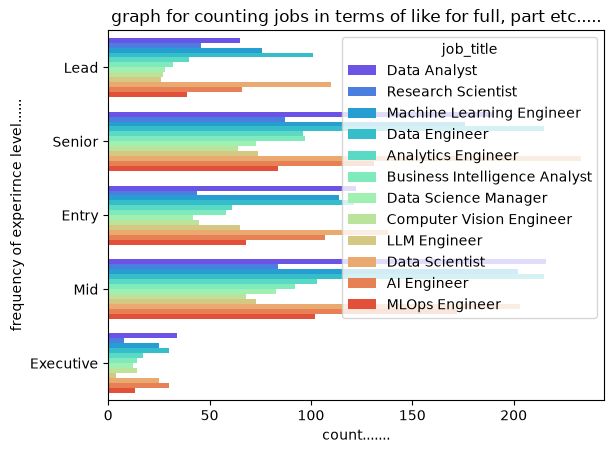

In [6]:
sns.countplot(y="experience_level",data=df,palette="rainbow",hue="job_title")
plt.title("graph for counting jobs in terms of like for full, part etc.....")
plt.ylabel("frequency of experirnce level......")
plt.xlabel("count.......")

In [8]:
df["employment_type"].value_counts()
# so my analysis is most of the employer are at full_time while some of them are for
 # contract, freelance and part time...

employment_type
Full-time    4159
Contract      418
Freelance     212
Part-time     211
Name: count, dtype: int64

Text(0.5, 0, 'Frequency.....')

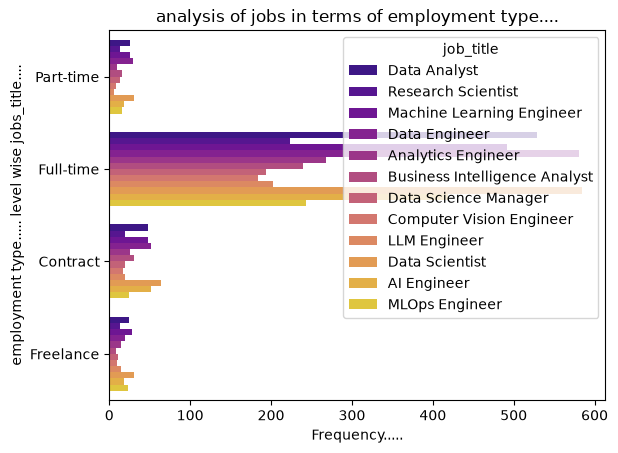

In [3]:
sns.countplot(y="employment_type",data=df,palette="plasma",hue="job_title")
plt.title("analysis of jobs in terms of employment type....")
plt.ylabel("employment type..... level wise jobs_title....")
plt.xlabel("Frequency.....")


In [6]:
# EDA analysis on the basis of company_size in this we will understand how jobs
 # are distributed in terms of company size like big, small medium etc

df["company_size"].value_counts()
# so my analysis is most of the company are like medium size that means thay are in growing 
 # phase so if we work there that means we the oppurtumity to help 

company_size
M    2551
L    1288
S    1161
Name: count, dtype: int64

Text(0.5, 0, 'Frequency.....')

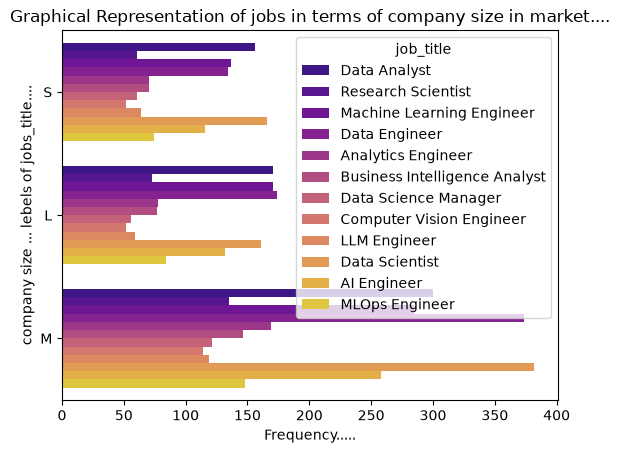

In [7]:
sns.countplot(y="company_size",data=df,hue="job_title",palette="plasma")
plt.title("Graphical Representation of jobs in terms of company size in market....")
plt.ylabel("company size ... lebels of jobs_title....")
plt.xlabel("Frequency.....")

### so my analysis is all company have an almost equal no of jobs in each department
### but the thing is generally people are prefare to join big company because of security region and long term growth.....

In [9]:
# Analysis of jobs in terms of Experience level.......
df["employment_type"].value_counts()

employment_type
Full-time    4159
Contract      418
Freelance     212
Part-time     211
Name: count, dtype: int64

Text(0.5, 0, 'Frequency....')

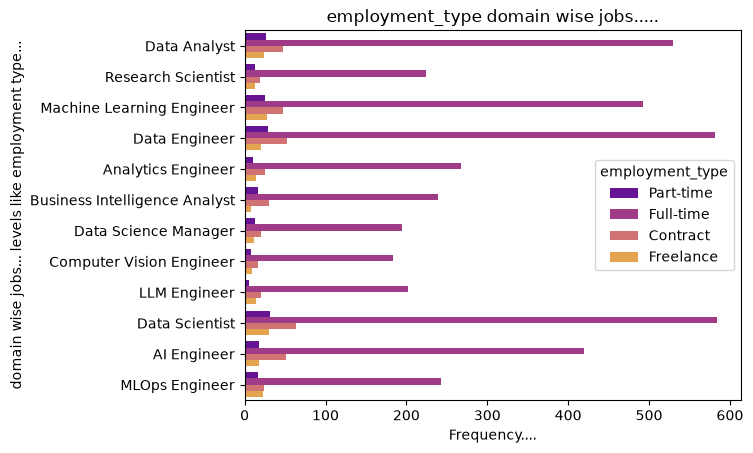

In [12]:
sns.countplot(y="job_title",data=df,palette="plasma",hue="employment_type")
plt.title("employment_type domain wise jobs.....")
plt.ylabel("domain wise jobs... levels like employment type...")
plt.xlabel("Frequency....")

Text(0.5, 0, 'freauency....')

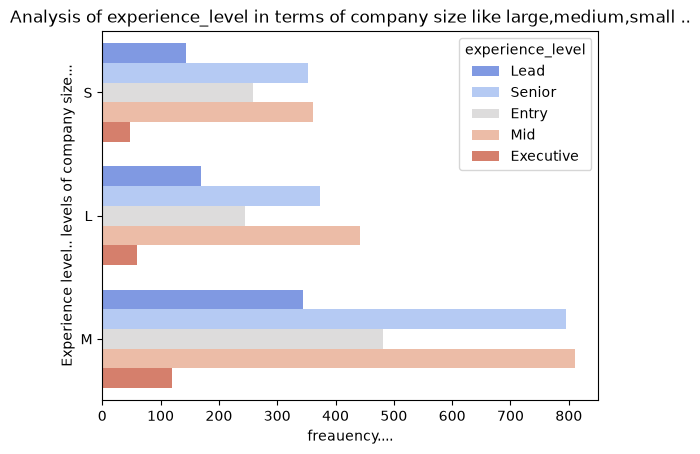

In [4]:
# analysis of experience level on the basis of company size....
sns.countplot(y="company_size",hue="experience_level",data=df,palette="coolwarm")
plt.title("Analysis of experience_level in terms of company size like large,medium,small ..")
plt.ylabel("Experience level.. levels of company size...")
plt.xlabel("freauency....")


### so my analysis is every company has jobs for each experience level but the thing is that generally employer are prefer large company for long term growth and for security rather than medium and small company....

In [ ]:
# Analysis of jobs location wise......
df["company_location"].value_counts()
# so most of the company are working inusa but some of them are working in india, great britan eccc


company_location
US    1786
IN     782
GB     488
DE     350
CA     350
AU     240
BR     210
NL     200
FR     189
PL     147
SG     130
ES     128
Name: count, dtype: int64

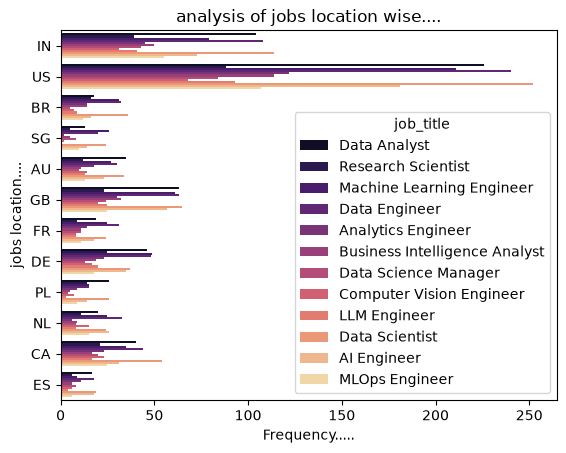

In [19]:
plt.Figure(figsize=(10,10))
sns.countplot(y="company_location",hue="job_title",data=df,palette="magma")
plt.title("analysis of jobs location wise....")
plt.xlabel("Frequency.....")
plt.ylabel("jobs location....")
plt.show()

In [26]:
# analysis of jobs on the basis of employee residence......
df["employee_residence"].value_counts()
# so most of the employer are from usa , india , Gb .....

employee_residence
US    1796
IN     776
GB     489
DE     362
CA     354
AU     243
NL     206
BR     205
FR     173
PL     148
ES     129
SG     119
Name: count, dtype: int64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_25544\3044486367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="employee_residence",data=df,order=df["employee_residence"].value_counts().index,palette="viridis")


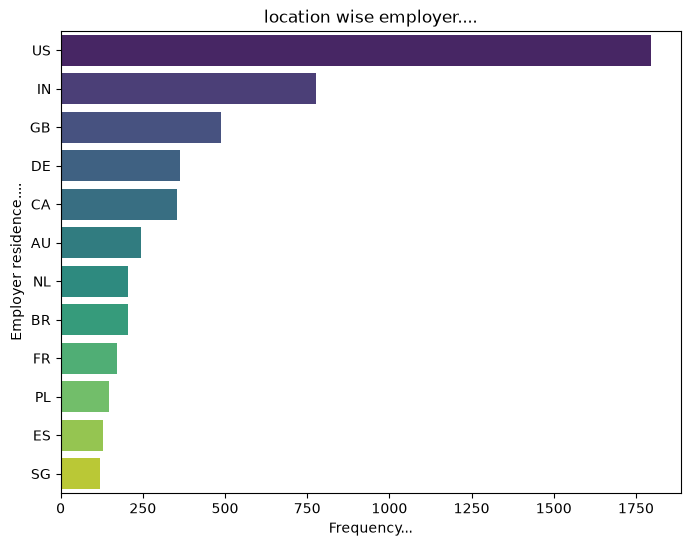

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(y="employee_residence",data=df,order=df["employee_residence"].value_counts().index,palette="viridis")
plt.title("location wise employer....")
plt.ylabel("Employer residence....")
plt.xlabel("Frequency...")
plt.show()

### so my of the employer are from usa, india because most of the company are located in usa,india so that could be the region...........

In [15]:
# now we are doing analysis on the basis of industry like finance,retail,government etc
df["industry"].value_counts()
## so most of the company are of like techonology industry but some of them are from
## finance , Heathcare etc....


industry
Technology       1528
Finance           839
Healthcare        543
Retail            452
Consulting        442
Manufacturing     302
Media             268
Government        254
Education         196
Energy            176
Name: count, dtype: int64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_25544\2778561424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="industry",data=df,order=df["industry"].value_counts().index,palette="coolwarm")


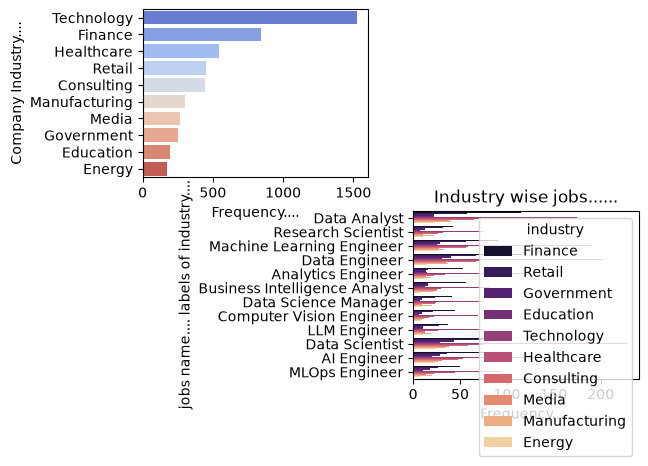

In [30]:
plt.Figure(figsize=(20,20))
plt.subplot(2,2,1)
sns.countplot(y="industry",data=df,order=df["industry"].value_counts().index,palette="coolwarm")
plt.ylabel("Company Industry....")
plt.xlabel("Frequency....")

plt.subplot(2,2,4)
sns.countplot(y="job_title",data=df,hue="industry",palette="magma")
plt.title("Industry wise jobs......")
plt.ylabel("jobs name.... labels of industry....")
plt.xlabel("Frequency.....")
plt.show()





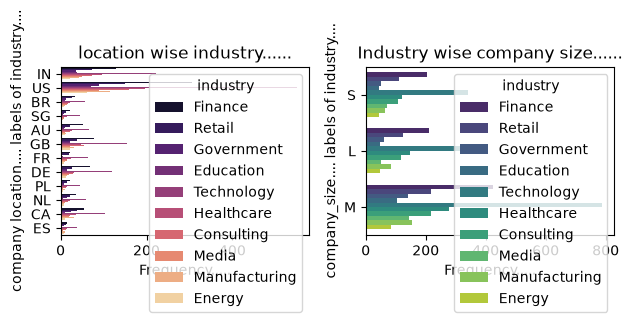

In [32]:
plt.subplot(2,2,2)
sns.countplot(y="company_size",data=df,hue="industry",palette="viridis")
plt.title("Industry wise company size......")
plt.ylabel("company_size.... labels of industry....")
plt.xlabel("Frequency.....")

plt.subplot(2,2,1)
sns.countplot(y="company_location",data=df,hue="industry",palette="magma")
plt.title("location wise industry......")
plt.ylabel("company location.... labels of industry....")
plt.xlabel("Frequency.....")
plt.tight_layout()
plt.show()

In [34]:
### Remote Work Analysis 🏠
df["remote_ratio"].value_counts()
## so my analysis is most of the employers are doing work from company office while some 
## of them are 50 remote raion means they are doing his works from both office & home
## while some of the workers are working full from home....

remote_ratio
0      2112
50     1468
100    1420
Name: count, dtype: int64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_25544\2672594242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="remote_ratio",data=df,palette="plasma",order=df["remote_ratio"].value_counts().index)


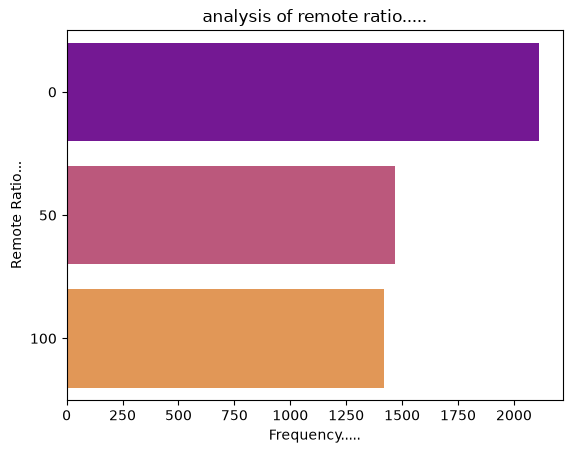

In [36]:
plt.Figure(figsize=(10,8))
sns.countplot(y="remote_ratio",data=df,palette="plasma",order=df["remote_ratio"].value_counts().index)
plt.title("analysis of remote ratio.....")
plt.ylabel("Remote Ratio...")
plt.xlabel("Frequency.....")
plt.show()

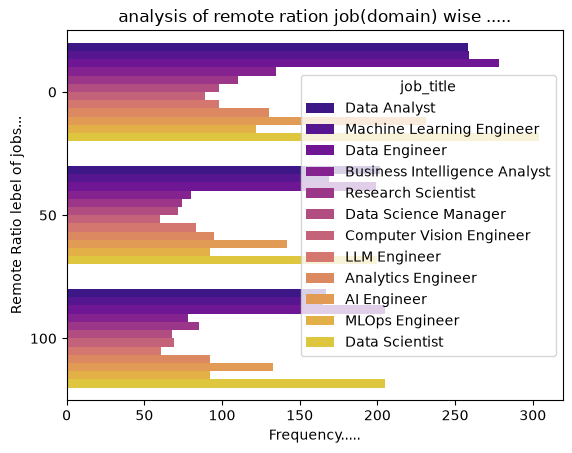

In [37]:
# Domain wise remote ratio analysis....
plt.Figure(figsize=(10,8))
sns.countplot(y="remote_ratio",data=df,palette="plasma",order=df["remote_ratio"].value_counts().index,hue="job_title")

plt.title("analysis of remote ration job(domain) wise .....")
plt.ylabel("Remote Ratio lebel of jobs...")
plt.xlabel("Frequency.....")
plt.show()

In [38]:
## now we are analyzing the numerical column years of experience.....
df["years_experience"].info()

<class 'pandas.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: years_experience
Non-Null Count  Dtype  
--------------  -----  
5000 non-null   float64
dtypes: float64(1)
memory usage: 39.2 KB


In [4]:
df["years_experience"].describe()
# describe is used to know all the statistical function of a given numerical column...
# so my analysis is avg. employers experience are like 8-10 yers while most experience emplotres are working since 23 yers


count    5000.000000
mean        8.361440
std         4.820808
min         0.000000
25%         4.800000
50%         8.100000
75%        11.500000
max        23.700000
Name: years_experience, dtype: float64

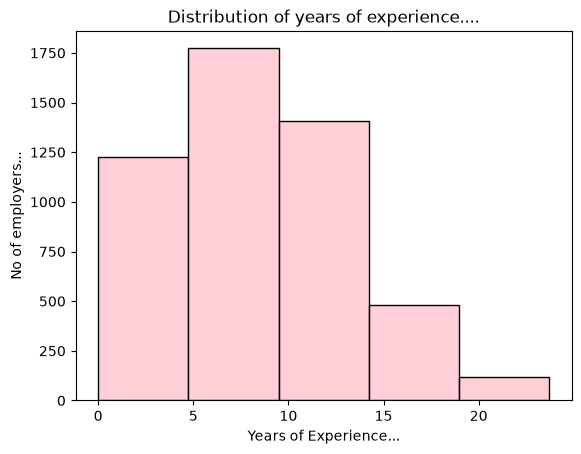

In [7]:
plt.Figure(figsize=(10,8))
sns.histplot(data=df,x="years_experience",bins=5,color="pink")
plt.title("Distribution of years of experience....")
plt.xlabel("Years of Experience...")
plt.ylabel("No of employers...")
plt.show()

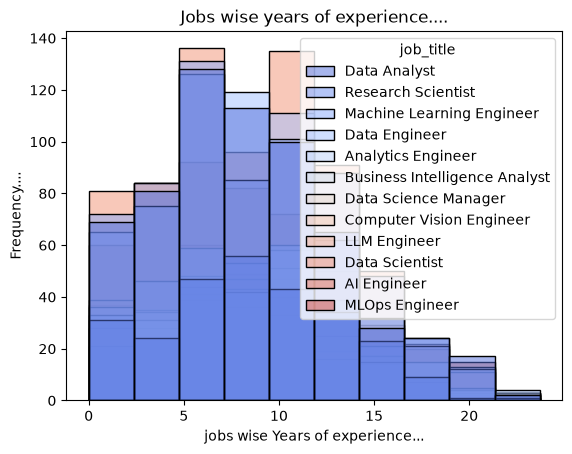

In [7]:
## analysis of jobs on the basis of years of experience....
plt.Figure(figsize=(20,10))
sns.histplot(data=df,x="years_experience",hue="job_title",bins=10,palette="coolwarm")
plt.title("Jobs wise years of experience....")
plt.xlabel("jobs wise Years of experience...")
plt.ylabel("Frequency....")
plt.show()




In [5]:
## analysis based on education level.....
df["education_level"].value_counts()

education_level
Bachelors      1903
Masters        1786
PhD             535
Bootcamp        473
Self-taught     303
Name: count, dtype: int64

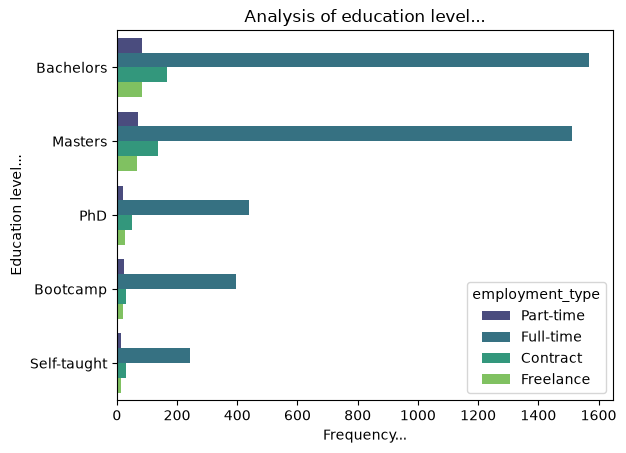

In [10]:
plt.Figure(figsize=(10,8),dpi=200)
sns.countplot(y="education_level",data=df,palette="viridis",order=df["education_level"].value_counts().index,hue="employment_type")
plt.title("Analysis of education level...")
plt.ylabel("Education level...")
plt.xlabel("Frequency...")

plt.show()

In [5]:
# analysis on the basis of primary language....
df["primary_language"].value_counts()
## so my analysis is most of the employer are uses python as primary language while some 
## of them are also use SQL, R etc as primary language for working...


primary_language
Python    3129
SQL        923
R          290
Java       259
Scala      219
Julia      102
Rust        78
Name: count, dtype: int64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_19664\3886615347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="primary_language",data=df,palette="magma",order=df["primary_language"].value_counts().index)


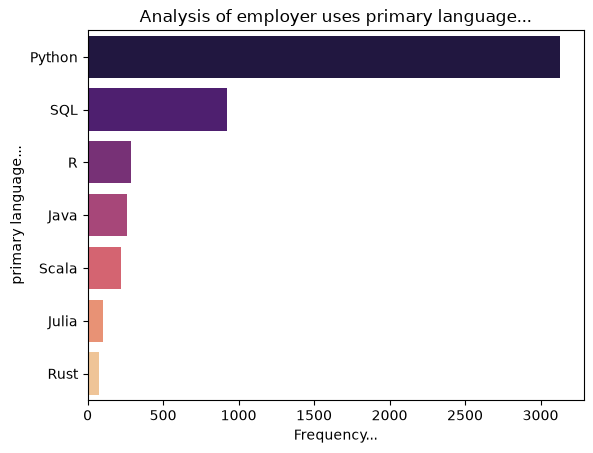

In [7]:
plt.Figure(figsize=(10,8),dpi=200)
sns.countplot(y="primary_language",data=df,palette="magma",order=df["primary_language"].value_counts().index)

plt.title("Analysis of employer uses primary language...")
plt.ylabel("primary language...")
plt.xlabel("Frequency...")

plt.show()

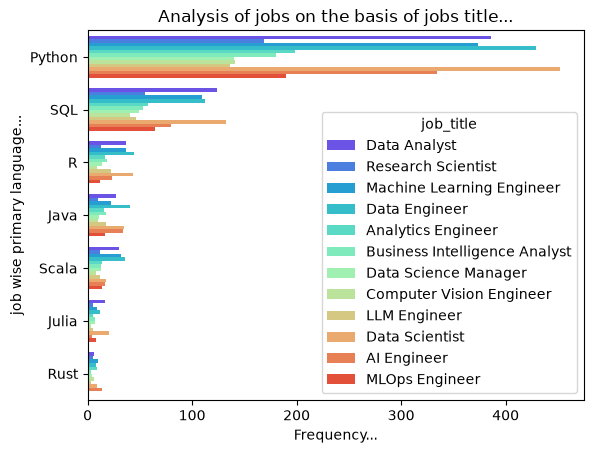

In [8]:
## analysis of jobs on the basis of primary language....
plt.Figure(figsize=(10,8),dpi=200)
sns.countplot(y="primary_language",data=df,palette="rainbow",order=df["primary_language"].value_counts().index,hue="job_title")

plt.title("Analysis of jobs on the basis of jobs title...")
plt.ylabel("job wise primary language...")
plt.xlabel("Frequency...")

plt.show()

### STAGE 4 — Salary & Job-Market Relationships


In [12]:
## 1. Does experience affect salary?
experience_salary = (
    df.groupby("experience_level")["salary_usd"]
      .agg(["count", "mean", "median","min","max"])
      .sort_values("median", ascending=False)
)

experience_salary

,count,mean,median,min,max
experience_level,,,,,
Executive,226,164659.194690,169078.0,23958,361230
Lead,656,136346.597561,131778.0,23826,352584
Senior,1520,109747.303947,108793.5,15528,372347
Mid,1613,86464.457533,85930.0,12000,259057
Entry,985,61002.652792,59851.0,12000,171884


C:\Users\MSI2\AppData\Local\Temp\ipykernel_19664\599669054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


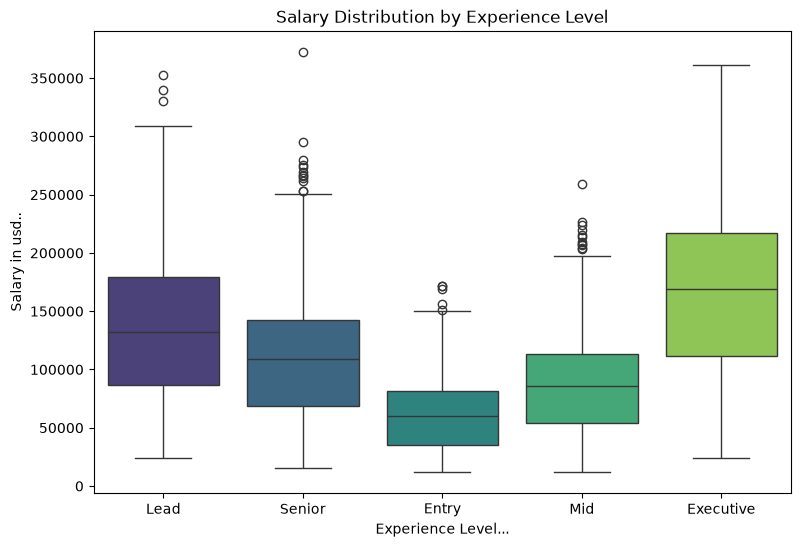

In [14]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_usd",
    palette="viridis"
)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level...")
plt.ylabel("Salary in usd..")
plt.show()

In [15]:
## ### Observation
# # The boxplot shows how salary distributions differ across experience levels.
# Higher experience levels generally show ___high___ salary distributions,
# while entry-level roles show ___low___ salary distributions.

In [26]:
## Job Title vs Salary 💼💰
job_wise_salary=df.groupby("job_title")["salary_usd"].median().sort_values(ascending=False)
job_wise_salary
## so my analysis is highest paying jobs are like  data science manager, llm engineer ,ai engineer etc


job_title
LLM Engineer                     107354.0
Research Scientist               105886.0
Machine Learning Engineer        105327.0
Data Science Manager             103948.5
Computer Vision Engineer         103856.0
AI Engineer                      101191.5
Data Engineer                     91588.0
MLOps Engineer                    89506.0
Data Scientist                    89478.0
Analytics Engineer                85632.0
Business Intelligence Analyst     71336.0
Data Analyst                      70371.0
Name: salary_usd, dtype: float64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_10584\1703424714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="salary_usd",y="job_title",palette="rainbow",data=df,estimator="median")


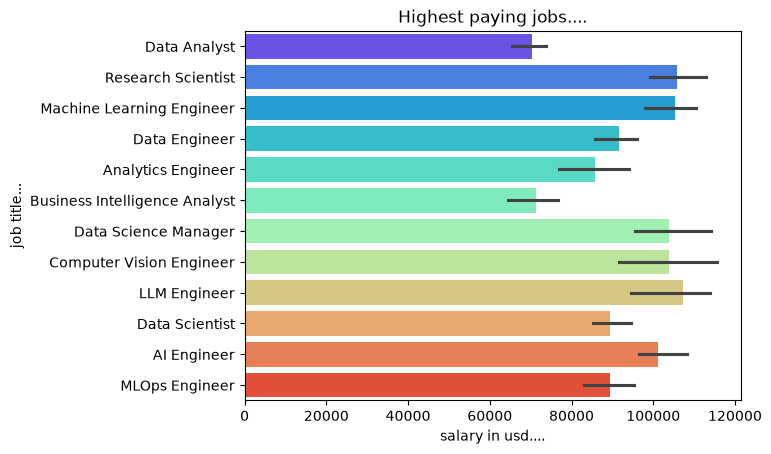

In [3]:
plt.Figure(figsize=(10,8))
sns.barplot(x="salary_usd",y="job_title",palette="rainbow",data=df,estimator="median")
plt.title("Highest paying jobs....")
plt.ylabel("job title...")
plt.xlabel("salary in usd....")
plt.show()

In [11]:
## Company Size vs Salary 🏢
company_salary = (
    df.groupby("company_size")["salary_usd"]
      .agg(["count", "mean", "median","max","min"])
)

company_salary
## so my analysis is large company are paying high money to the employer that's why 
## every employer wants to work in big company...


,count,mean,median,max,min
company_size,,,,,
L,1288,113400.975155,104877.5,372347,12000
M,2551,97986.648373,91518.0,338452,12000
S,1161,83550.934539,77112.0,287379,12000


C:\Users\MSI2\AppData\Local\Temp\ipykernel_10584\1348685379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


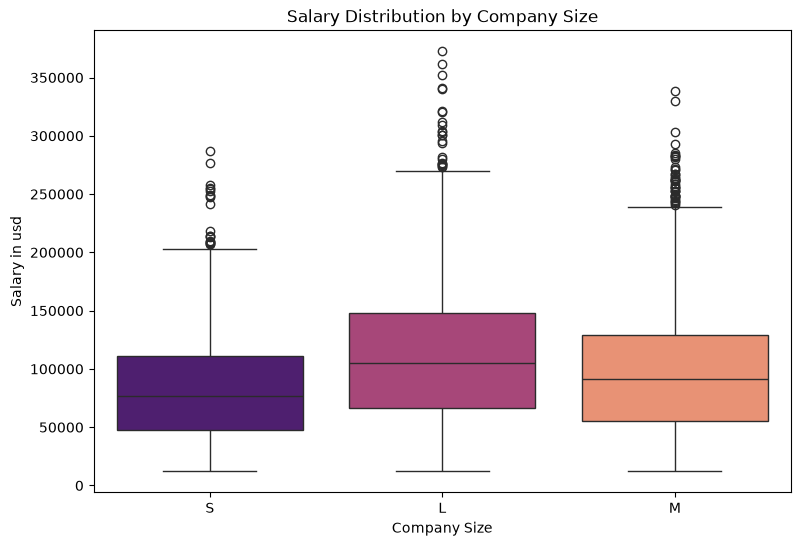

In [10]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="company_size",
    y="salary_usd",
    palette="magma"
)

plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary in usd")
plt.show()

In [15]:
### Remote Work vs Salary 🏠💰
df.groupby("remote_ratio")["salary_usd"].agg(["mean","median","max","min"])
## so my analysis is company are paying high to the 100 remote ratio employer...

,mean,median,max,min
remote_ratio,,,,
0,96257.100379,89584.5,372347,12000
50,99671.175749,90016.5,352584,12000
100,100996.302113,92495.0,361230,12000


C:\Users\MSI2\AppData\Local\Temp\ipykernel_10584\2382123296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


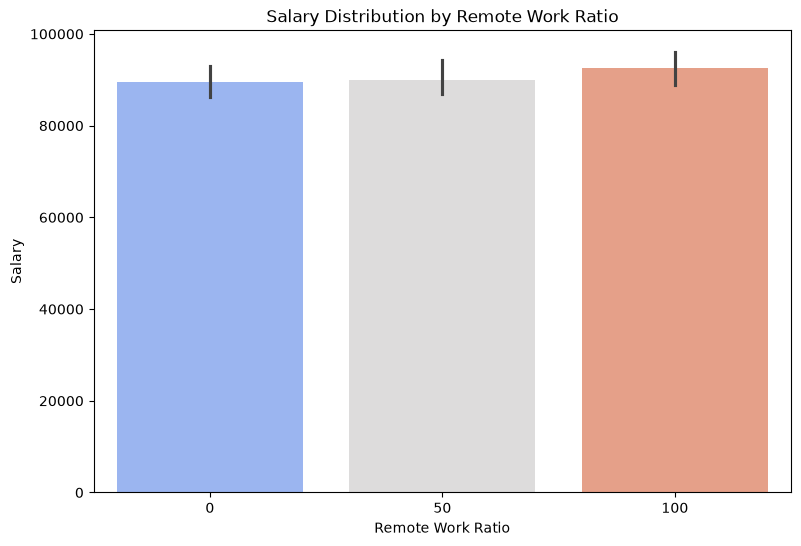

In [17]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="remote_ratio",
    y="salary_usd",
    palette="coolwarm",
    estimator="median"
)

plt.title("Salary Distribution by Remote Work Ratio")
plt.xlabel("Remote Work Ratio")
plt.ylabel("Salary")
plt.show()

In [20]:
## Employment Type vs Salary
employment_salary = (
    df.groupby("employment_type")["salary_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("median", ascending=False)
)

employment_salary
##  so my analysis is company are paying high money to the full time employer 

,count,mean,median
employment_type,,,
Full-time,4159,101688.347199,94545.0
Freelance,212,90354.844340,86794.5
Contract,418,93427.117225,84828.0
Part-time,211,56385.938389,49535.0


C:\Users\MSI2\AppData\Local\Temp\ipykernel_10584\2346959849.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


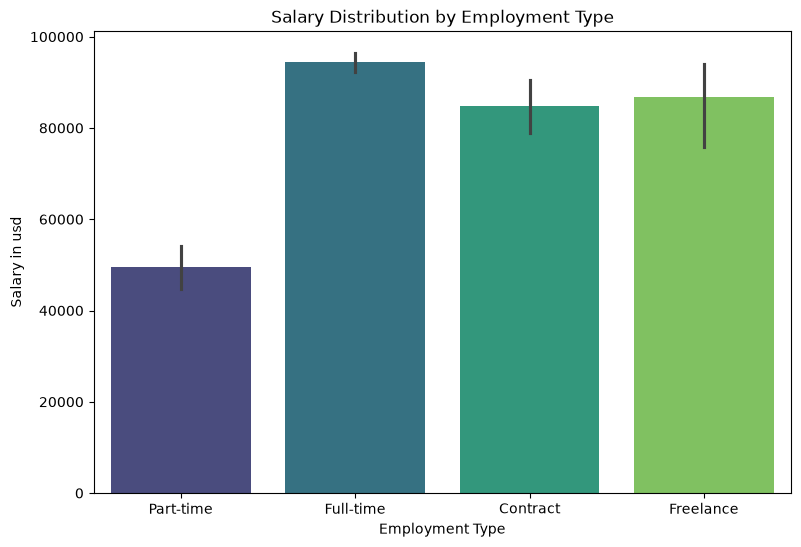

In [22]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="employment_type",
    y="salary_usd",
    palette="viridis",
    estimator="median"
)

plt.title("Salary Distribution by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Salary in usd")
plt.show()

### STAGE 5 — Job Demand Analysis

In [27]:
job_demand = df["job_title"].value_counts()

job_demand.head(15)
## so my analysis is some of most demand jobs in market are like data scientist,data engineer
## , data analyst etc

job_title
Data Scientist                   709
Data Engineer                    682
Data Analyst                     627
Machine Learning Engineer        593
AI Engineer                      506
Analytics Engineer               317
MLOps Engineer                   306
Business Intelligence Analyst    293
Research Scientist               269
LLM Engineer                     242
Data Science Manager             238
Computer Vision Engineer         218
Name: count, dtype: int64

C:\Users\MSI2\AppData\Local\Temp\ipykernel_10584\2940008423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


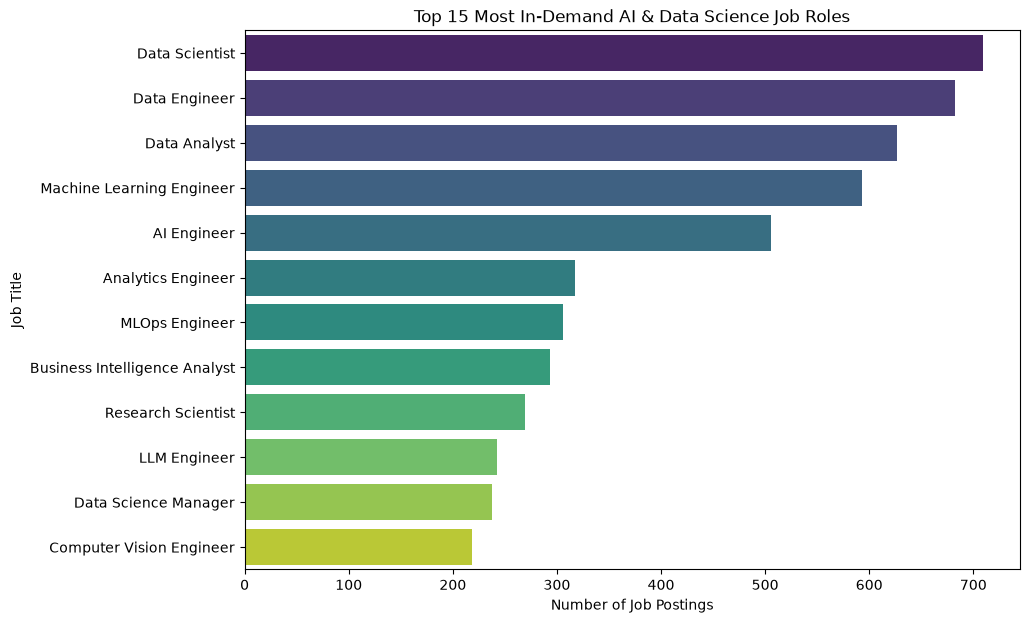

In [26]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=job_demand.head(15).values,
    y=job_demand.head(15).index,
    palette="viridis"
)

plt.title("Top 15 Most In-Demand AI & Data Science Job Roles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.show()

In [30]:
job_demand_percentage = (
    df["job_title"]
    .value_counts(normalize=True)
    .head(15) * 100
)

job_demand_percentage

job_title
Data Scientist                   14.18
Data Engineer                    13.64
Data Analyst                     12.54
Machine Learning Engineer        11.86
AI Engineer                      10.12
Analytics Engineer                6.34
MLOps Engineer                    6.12
Business Intelligence Analyst     5.86
Research Scientist                5.38
LLM Engineer                      4.84
Data Science Manager              4.76
Computer Vision Engineer          4.36
Name: proportion, dtype: float64

In [31]:
## Job Title × Experience Level 🔥
job_experience = pd.crosstab(
    df["job_title"],
    df["experience_level"]
)

job_experience

experience_level,Entry,Executive,Lead,Mid,Senior
job_title,,,,,
AI Engineer,107,30,66,172,131
Analytics Engineer,61,17,40,103,96
Business Intelligence Analyst,58,14,32,92,97
Computer Vision Engineer,45,14,27,68,64
Data Analyst,122,34,65,216,190
Data Engineer,121,30,101,215,215
Data Science Manager,42,12,28,83,73
Data Scientist,138,25,110,203,233
LLM Engineer,65,4,26,73,74


In [32]:
top_jobs = df["job_title"].value_counts().head(10).index

job_experience_top = job_experience.loc[top_jobs]

job_experience_top

experience_level,Entry,Executive,Lead,Mid,Senior
job_title,,,,,
Data Scientist,138,25,110,203,233
Data Engineer,121,30,101,215,215
Data Analyst,122,34,65,216,190
Machine Learning Engineer,114,25,76,202,176
AI Engineer,107,30,66,172,131
Analytics Engineer,61,17,40,103,96
MLOps Engineer,68,13,39,102,84
Business Intelligence Analyst,58,14,32,92,97
Research Scientist,44,8,46,84,87


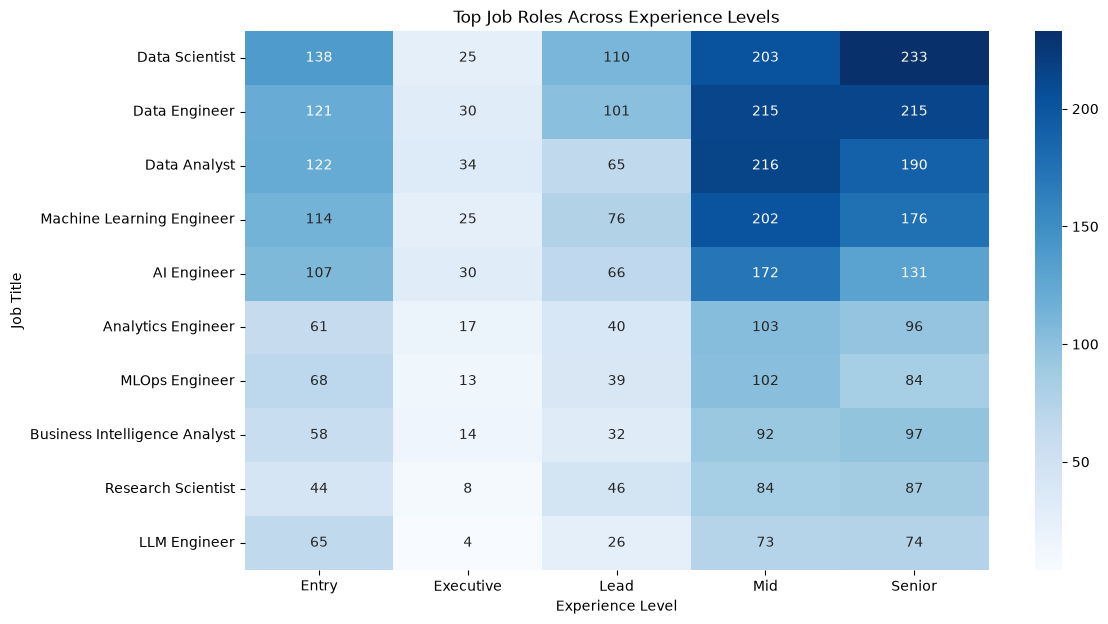

In [33]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    job_experience_top,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Top Job Roles Across Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Job Title")
plt.show()

In [34]:
## Location-Based Job Demand 🌍
df.groupby("company_location")["job_title"].value_counts()

company_location  job_title                
AU                Data Analyst                  35
                  Data Scientist                34
                  Data Engineer                 30
                  Machine Learning Engineer     27
                  AI Engineer                   23
                                              ... 
US                MLOps Engineer               107
                  LLM Engineer                  93
                  Research Scientist            88
                  Data Science Manager          84
                  Computer Vision Engineer      68
Name: count, Length: 144, dtype: int64

In [35]:
location_demand = df["company_location"].value_counts()

location_demand.head(15)

company_location
US    1786
IN     782
GB     488
DE     350
CA     350
AU     240
BR     210
NL     200
FR     189
PL     147
SG     130
ES     128
Name: count, dtype: int64

In [48]:
## Company Size × Job Demand 🏢
ct=pd.crosstab(df["company_size"],
            df["job_title"])
ct

job_title,AI Engineer,Analytics Engineer,Business Intelligence Analyst,Computer Vision Engineer,Data Analyst,Data Engineer,Data Science Manager,Data Scientist,LLM Engineer,MLOps Engineer,Machine Learning Engineer,Research Scientist
company_size,,,,,,,,,,,,
L,132,78,77,52,171,174,56,161,59,84,171,73
M,258,169,146,114,300,374,121,382,119,148,285,135
S,116,70,70,52,156,134,61,166,64,74,137,61


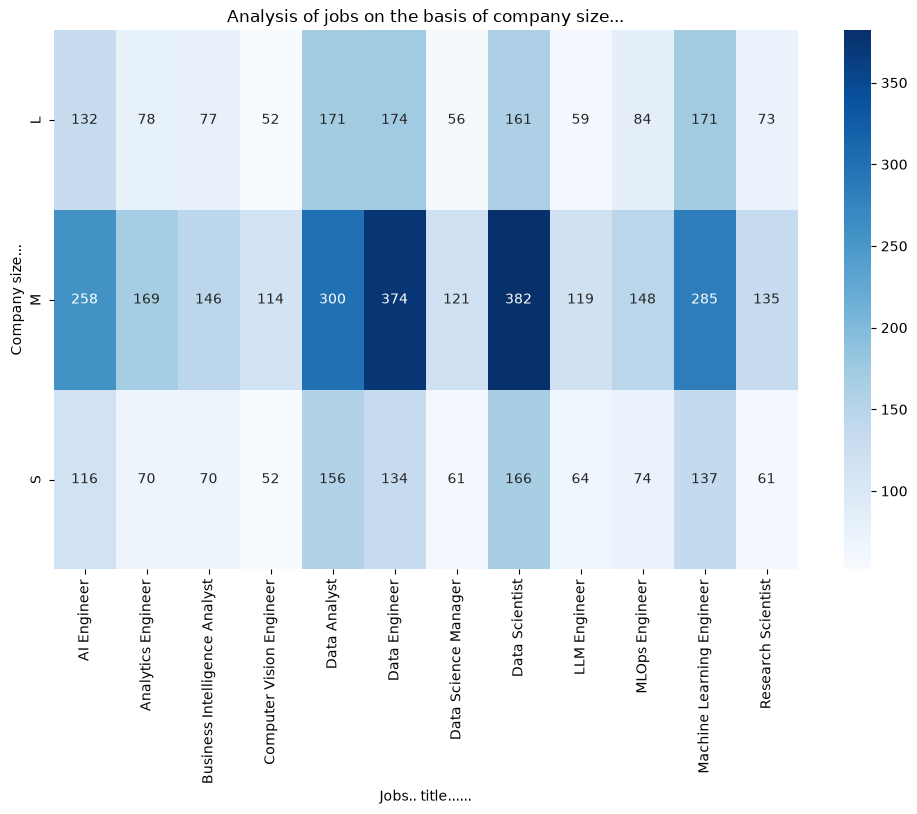

In [56]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Analysis of jobs on the basis of company size...")
plt.xlabel("Jobs.. title......")
plt.ylabel("Company size...")
plt.show()

In [52]:
## Remote Job Demand
ct_of_rjd=pd.crosstab(
    df["remote_ratio"],
    df["job_title"]

)
ct_of_rjd

job_title,AI Engineer,Analytics Engineer,Business Intelligence Analyst,Computer Vision Engineer,Data Analyst,Data Engineer,Data Science Manager,Data Scientist,LLM Engineer,MLOps Engineer,Machine Learning Engineer,Research Scientist
remote_ratio,,,,,,,,,,,,
0,231,130,135,89,258,278,98,304,98,122,259,110
50,142,95,80,60,202,199,72,200,83,92,169,74
100,133,92,78,69,167,205,68,205,61,92,165,85


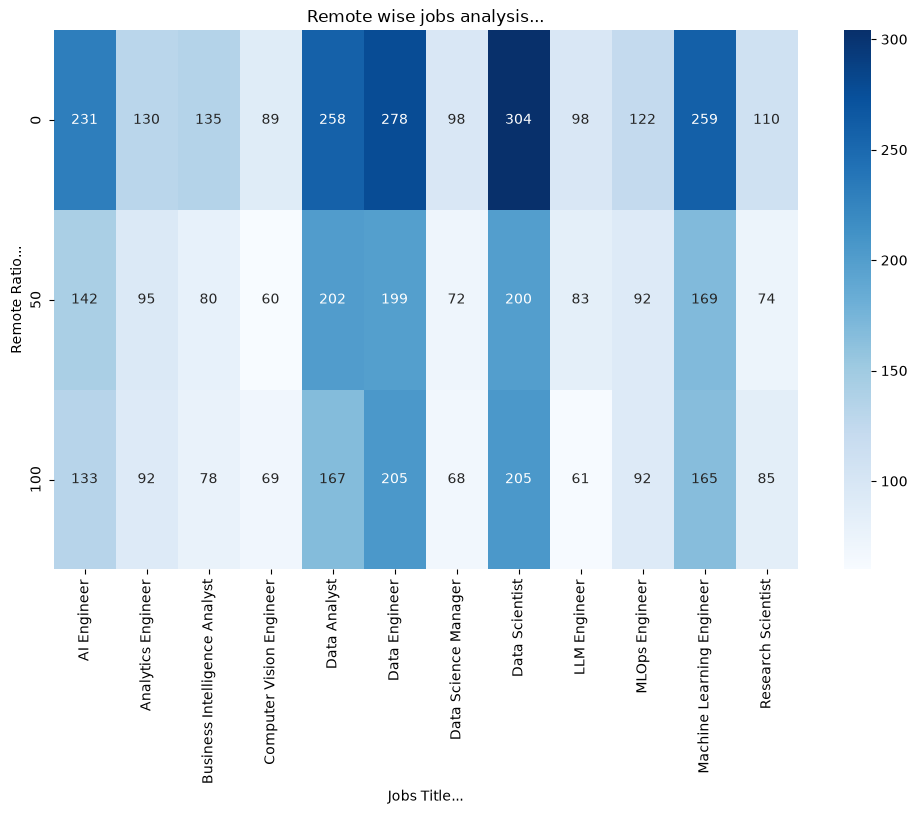

In [58]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    ct_of_rjd,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Remote wise jobs analysis...")
plt.xlabel("Jobs Title...")
plt.ylabel("Remote Ratio...")
plt.show()

# Create a Job-Market Summary Table

In [60]:
job_summary = (
    df.groupby("job_title")
      .agg(
          job_count=("job_title", "size"),
          median_salary=("salary_usd", "median"),
          average_salary=("salary_usd", "mean")
      )
      .sort_values("job_count", ascending=False)
)

job_summary.head(15)

,job_count,median_salary,average_salary
job_title,,,
Data Scientist,709,89478.0,94938.994358
Data Engineer,682,91588.0,100878.351906
Data Analyst,627,70371.0,75498.746411
Machine Learning Engineer,593,105327.0,110434.210793
AI Engineer,506,101191.5,110903.478261
Analytics Engineer,317,85632.0,90432.249211
MLOps Engineer,306,89506.0,98587.718954
Business Intelligence Analyst,293,71336.0,75004.313993
Research Scientist,269,105886.0,109608.479554


In [63]:
## Find "High Demand + High Salary" Jobs......
df.groupby("job_title")["salary_usd"].median().sort_values(ascending=False)

job_title
LLM Engineer                     107354.0
Research Scientist               105886.0
Machine Learning Engineer        105327.0
Data Science Manager             103948.5
Computer Vision Engineer         103856.0
AI Engineer                      101191.5
Data Engineer                     91588.0
MLOps Engineer                    89506.0
Data Scientist                    89478.0
Analytics Engineer                85632.0
Business Intelligence Analyst     71336.0
Data Analyst                      70371.0
Name: salary_usd, dtype: float64

In [64]:
high_demand_high_salary = job_summary[
    job_summary["job_count"] >= 10
].sort_values(
    "median_salary",
    ascending=False
)

high_demand_high_salary.head(15)

,job_count,median_salary,average_salary
job_title,,,
LLM Engineer,242,107354.0,110920.231405
Research Scientist,269,105886.0,109608.479554
Machine Learning Engineer,593,105327.0,110434.210793
Data Science Manager,238,103948.5,114440.697479
Computer Vision Engineer,218,103856.0,108249.977064
AI Engineer,506,101191.5,110903.478261
Data Engineer,682,91588.0,100878.351906
MLOps Engineer,306,89506.0,98587.718954
Data Scientist,709,89478.0,94938.994358


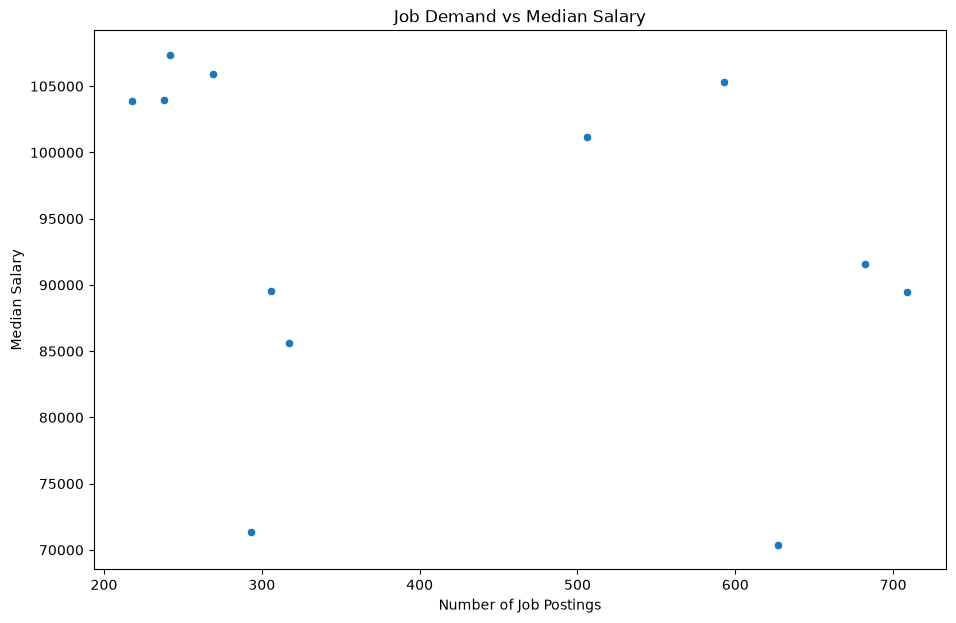

In [65]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=job_summary,
    x="job_count",
    y="median_salary"
)

plt.title("Job Demand vs Median Salary")
plt.xlabel("Number of Job Postings")
plt.ylabel("Median Salary")
plt.show()

In [ ]:
## Key Findings

# - The most frequently occurring job titles were _data engineer and data scientist_____.
# - ______ experience level had the highest number of postings.
# - The largest concentration of job opportunities came from ______.
# - ______ job roles showed strong representation across experience levels.
# - Remote opportunities were particularly visible in ______ roles.
# - The relationship between job demand and salary varied across roles.

# STAGE 6 — Advanced Insights & Data Storytelling

In [3]:
## Mean vs Median Salary 💰
salary_stats = df["salary_usd"].agg(
    ["count", "min", "max", "mean", "median", "std"]
)

salary_stats

count       5000.000000
min        12000.000000
max       372347.000000
mean       98605.406200
median     90572.000000
std        55369.310473
Name: salary_usd, dtype: float64

In [4]:
print("Mean Salary:", df["salary_usd"].mean())
print("Median Salary:", df["salary_usd"].median())

Mean Salary: 98605.4062
Median Salary: 90572.0


In [5]:
### Correlation Analysis 📊
numeric_columns = df.select_dtypes(
    include="number"
)

correlation = numeric_columns.corr()

correlation

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
remote_ratio,1.000000,0.000817,0.015932,0.012334,0.002597,-0.003021,0.036407,-0.005855,-0.007357,0.200945,-0.015229,0.003872,-0.011549
years_experience,0.000817,1.000000,-0.010405,0.215552,0.260733,0.060093,0.466250,-0.012635,0.609849,0.023550,0.290221,-0.132696,-0.253683
team_size,0.015932,-0.010405,1.000000,0.021003,-0.012687,-0.002507,0.021266,-0.006089,-0.012298,0.022383,0.002055,0.010185,-0.009026
certifications_count,0.012334,0.215552,0.021003,1.000000,0.050964,0.006781,0.107841,0.005295,0.168985,0.018491,0.074464,-0.035547,-0.057315
weekly_hours,0.002597,0.260733,-0.012687,0.050964,1.000000,0.026934,0.133520,-0.017489,0.173516,-0.227398,0.077898,-0.047595,-0.066211
ai_tools_hours_per_week,-0.003021,0.060093,-0.002507,0.006781,0.026934,1.000000,0.080282,0.015728,0.046455,0.002153,0.022598,-0.026349,-0.067841
salary_usd,0.036407,0.466250,0.021266,0.107841,0.133520,0.080282,1.000000,-0.111595,0.328451,0.179104,0.155130,-0.069662,-0.241418
equity_offered_pct,-0.005855,-0.012635,-0.006089,0.005295,-0.017489,0.015728,-0.111595,1.000000,0.000473,-0.013130,-0.020228,0.029643,0.004312
bonus_pct,-0.007357,0.609849,-0.012298,0.168985,0.173516,0.046455,0.328451,0.000473,1.000000,0.041612,0.219709,-0.102634,-0.184005
job_satisfaction_score,0.200945,0.023550,0.022383,0.018491,-0.227398,0.002153,0.179104,-0.013130,0.041612,1.000000,0.014655,0.011806,-0.043140


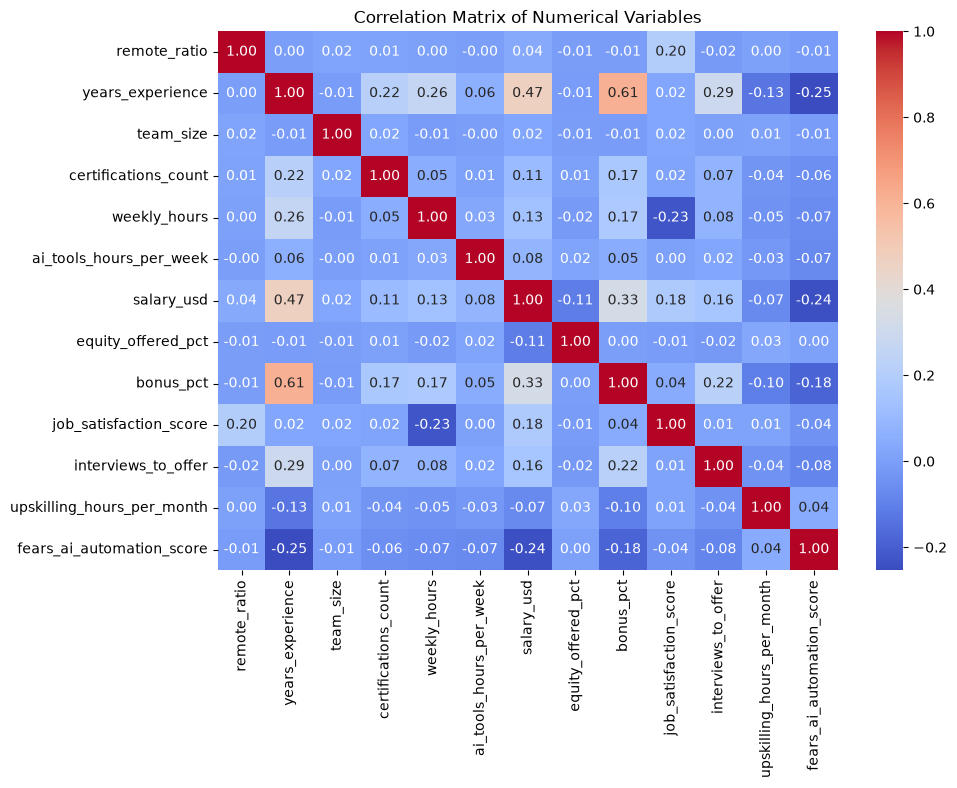

In [6]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

### ### Correlation Analysis — Key Findings

- Years of experience has a moderate positive correlation with salary
  (r = 0.47), suggesting that more experienced professionals tend
  to earn higher salaries.

- Years of experience has a relatively strong positive correlation
  with bonus percentage (r = 0.61).

- Salary and bonus percentage show a weak-to-moderate positive
  correlation (r = 0.33).

- Years of experience has a weak negative correlation with fear of
  AI automation (r = -0.25).

- Salary also shows a weak negative correlation with fear of AI
  automation (r = -0.24).

- Several variables, including team size and AI-tool usage hours,
  show very weak correlations with salary.

> Note: Correlation indicates association, not causation.

# # 💡 Key Insights

### 1. Job Demand 
so my analysis most of the company need more employer in the field like data scientist,
data engineer , data analyst etc and this domain has oppourtunity for all level of employee like fresher, freelance, experirnced and within good salary and their long term growth are  also good .....
### 2.  Experience
so my analysis is generally experienced employer are getting more salary and are often 
hire for full time and feel more secure  in the coorporate life......

### 3. Salary
so my analysis is generally large company offers more salary in the specific domain like LLM engineer , data research scientist,ai engineer etc that's why this type is in 
more demand and when you get some experience then you will get more salary.....
### 4. Remote Work 
so my analysis is 0 remote ratio employee are demand more in market but 50 and 100 
remote ratio employer are also working in this field but the thing is 0 remote ratio employer are getting more salary than 50 and 100 ......
### 5. Location
so my analysis is most of the company are located in usa, india so most of the employer are from india and usa but usa employer are getting more salary because 
generally most of the usa company has big name in market.....





# Recommendations 🎯

### 1. Focus on high-demand roles
you  should consider popular roles such as Data Scientist, Data Engineer, Data Analyst, and other frequently occurring AI/Data Science positions.
### 2. Build skills according to the target role
Instead of learning everything, you should develop skills that are directly related to their chosen specialization(domain).
### 3. Gain experience gradually
Since experience shows a positive relationship with salary in the dataset, you should focus on internships, projects, freelancing, and entry-level opportunities to build experience.
### 4. Develop a strong technical portfolio
 create some practical projects related to your target job role to demonstrate their skills to employers.
 ### 5. Consider remote opportunities
if you are  interested in remote work should explore job roles and experience levels where remote opportunities are more common in the dataset.
### 6. Compare salary using median values
Employer should consider median salary rather than only average salary because salary data can contain extreme values.
### 7. Look for the balance between demand and salary
You can prioritize roles that show both relatively high job demand and competitive median salaries rather than focusing only on the highest salary.
### 8. Higher experience can improve earning potential
The positive relationship between years_experience and salary_usd suggests that developing experience can be valuable for long-term earning potential.

# 🏁 Conclusion

This project helped me understand the AI and Data Science job market using real data.

I analyzed job roles, salaries, experience levels, remote jobs, locations, and other factors.

I found that job demand and salary can be different for different roles and experience levels. I also found that experience has a positive relationship with salary.

Overall, this project helped me understand how Python and data analysis can be used to find useful patterns from a dataset.

# 🛠️ Technologies Used

- Python – Main programming language used for the project.
- Pandas – Used for data loading, cleaning, filtering, grouping, and analysis.
- NumPy – Used for numerical operations.
- Matplotlib – Used for creating charts and graphs.
- Seaborn – Used for creating statistical visualizations.
- Jupyter Notebook – Used to write and run the analysis step by step.
- VS Code – Used for developing and managing the project.
- CSV – Used as the main dataset format.